---
# Regression Tree (CART) From Scratch  
**Dataset:** Car Evaluation (categorical predictors)   
---

## 1. What we are building

A regression tree (CART) is a supervised learning model that predicts a numeric value using a hierarchy of if–then split rules.

Unlike linear models, regression trees partition the feature space into disjoint regions and assign each region a constant prediction. Under squared loss, the optimal prediction at any leaf is the mean of the target values in that region.

At each internal node, the algorithm evaluates candidate splits and selects the one that minimizes the total sum of squared errors (SSE):

$$\text{SSE}_{\text{split}} = \text{SSE}_{\text{left}} + \text{SSE}_{\text{right}}$$

In this notebook, we apply a from-scratch CART regression tree (implemented in `src/rice_ml`) to the Car Evaluation dataset, which consists entirely of categorical predictors.

Although the original target is categorical (`unacc`, `acc`, `good`, `vgood`), we encode it as an ordinal numeric score and treat the task as a regression problem. This allows us to study how feature conditions shift the expected evaluation score.
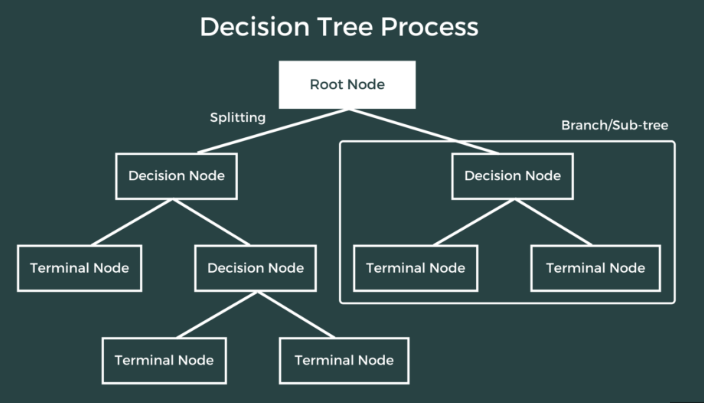

## 2. Setup and Imports
This section imports all required libraries and ensures the custom regression tree implementation from the `rice_ml` package can be imported correctly.

No machine-learning algorithms from external libraries (e.g., scikit-learn) are used. All modeling logic comes from the source code in `src/`.

In [ ]:
import os
import itertools
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append(os.path.abspath("../../../src"))
from rice_ml.supervised_learning.regression_trees import build_regression_tree, predict

DATA_PATH = "car_evaluation.csv"


## 3. Data Loading and Column Standardization

This cell loads the dataset from CSV or Excel. If the file does not contain a header row (a common format for the Car Evaluation dataset), the code assigns the standard column names. The output confirms the shape and shows the first rows for quick verification.

In [5]:
def load_table(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
        # If there is no header, pandas may interpret columns as numeric strings
        if all(str(c).isdigit() for c in df.columns):
            df = pd.read_csv(path, header=None)

    # Standard Car Evaluation dataset has 7 columns
    if df.shape[1] == 7:
        df.columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
    elif "class" not in df.columns:
        cols = list(df.columns)
        cols[-1] = "class"
        df.columns = cols

    return df

df_raw = load_table(DATA_PATH)

print("Loaded shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
df_raw.head()


Loaded shape: (1727, 7)
Columns: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## 4. Initial Data Quality Checks

This cell checks for three common data issues before cleaning: missing values, empty strings (after trimming whitespace), and duplicate rows. These diagnostics provide evidence that the dataset is suitable for modeling, or indicate what cleaning steps are required.

In [9]:
df = df_raw.copy()

print("Missing values per column:\n", df.isna().sum())

# Empty-string check after trimming (common hidden issue)
trimmed = df.astype(str).apply(lambda s: s.str.strip())
empty_counts = (trimmed == "").sum()
print("\nEmpty-string counts (after strip):\n", empty_counts)

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", int(dup_count))


Missing values per column:
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Empty-string counts (after strip):
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Duplicate rows: 0


## 5. Data Cleaning and Deduplication

This cell applies cleaning rules to ensure consistent inputs: keep only required columns, trim whitespace, and remove duplicate rows. The output reports how many records remain after deduplication.

In [10]:
EXPECTED_COLS = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

missing_cols = [c for c in EXPECTED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[EXPECTED_COLS].copy()

for c in EXPECTED_COLS:
    df[c] = df[c].astype(str).str.strip()

before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before drop_duplicates: {before}, after: {after}")
df.head()


Rows before drop_duplicates: 1727, after: 1727


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## 6. Category Validation Against Known Levels

This cell validates whether each feature and the target contain only expected category levels for the Car Evaluation dataset. Any unexpected categories are flagged as warnings, which helps catch formatting errors or data inconsistencies early.


In [11]:
KNOWN_CATS = {
    "buying": {"vhigh", "high", "med", "low"},
    "maint": {"vhigh", "high", "med", "low"},
    "doors": {"2", "3", "4", "5more"},
    "persons": {"2", "4", "more"},
    "lug_boot": {"small", "med", "big"},
    "safety": {"low", "med", "high"},
    "class": {"unacc", "acc", "good", "vgood"},
}

for col, known in KNOWN_CATS.items():
    observed = set(df[col].unique().tolist())
    unknown = observed - known
    if unknown:
        print(f"[Warning] {col} unexpected categories:", unknown)
    else:
        print(f"[OK] {col}: {sorted(list(observed))}")


[OK] buying: ['high', 'low', 'med', 'vhigh']
[OK] maint: ['high', 'low', 'med', 'vhigh']
[OK] doors: ['2', '3', '4', '5more']
[OK] persons: ['2', '4', 'more']
[OK] lug_boot: ['big', 'med', 'small']
[OK] safety: ['high', 'low', 'med']
[OK] class: ['acc', 'good', 'unacc', 'vgood']


## 7. Target Distribution Visualization

This cell visualizes the frequency distribution of the target labels (class). Reporting the target distribution is important for understanding class imbalance, interpreting results, and contextualizing evaluation metrics.

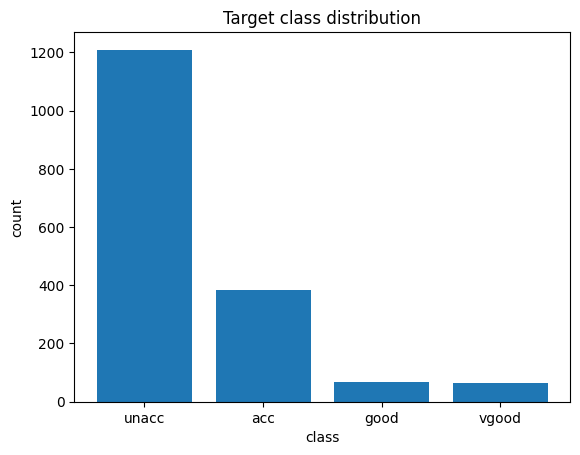

,count
class,
unacc,1209
acc,384
good,69
vgood,65


In [12]:
target_counts = df["class"].value_counts()

plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target class distribution")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

target_counts


## 8. Ordinal Target Encoding for Regression

Because a regression tree requires a numeric target, this cell encodes the ordinal class labels into numeric scores:
unacc=0,
acc=1,
good=2,
vgood=3.
This converts the label into an ordered numeric outcome that can be modeled using SSE minimization.

In [13]:
TARGET_MAP = {"unacc": 0.0, "acc": 1.0, "good": 2.0, "vgood": 3.0}
INV_TARGET_MAP = {v: k for k, v in TARGET_MAP.items()}

df["y"] = df["class"].map(TARGET_MAP).astype(float)

X_COLS = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
X_all = df[X_COLS].copy()
y_all = df["y"].to_numpy(dtype=float)

df[["class", "y"]].head(10)


,class,y
0,unacc,0.0
1,unacc,0.0
2,unacc,0.0
3,unacc,0.0
4,unacc,0.0
5,unacc,0.0
6,unacc,0.0
7,unacc,0.0
8,unacc,0.0
9,unacc,0.0


## 9. Deterministic Stratified Train/Test Split

To avoid any dependence on random seeds, this cell performs a deterministic stratified split: within each class group, the first 80% of rows are assigned to training and the remaining 20% to testing. This preserves class proportions while guaranteeing identical splits across repeated runs.

In [14]:
TEST_SIZE = 0.2

train_parts, test_parts = [], []

for cls_val, group in df.groupby("class", sort=False):
    n = len(group)
    cut = int(np.floor(n * (1.0 - TEST_SIZE)))
    train_parts.append(group.iloc[:cut])
    test_parts.append(group.iloc[cut:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

X_train = train_df[X_COLS].reset_index(drop=True)
y_train = train_df["y"].to_numpy(dtype=float)
X_test = test_df[X_COLS].reset_index(drop=True)
y_test = test_df["y"].to_numpy(dtype=float)

print("Train size:", len(train_df), "Test size:", len(test_df))
print("\nTrain class distribution:\n", train_df["class"].value_counts(normalize=True))
print("\nTest class distribution:\n", test_df["class"].value_counts(normalize=True))


Train size: 1381 Test size: 346

Train class distribution:
 class
unacc    0.700217
acc      0.222303
good     0.039826
vgood    0.037654
Name: proportion, dtype: float64

Test class distribution:
 class
unacc    0.699422
acc      0.222543
good     0.040462
vgood    0.037572
Name: proportion, dtype: float64


## 10. Training the From-Scratch Regression Tree

We now train a CART-style regression tree implemented entirely from scratch in the rice_ml package.

The model uses:
- Sum of squared errors (SSE) as the split criterion
- Greedy recursive splitting to minimize SSE at each node
- User-specified regularization parameters (max_depth, min_samples_split, min_samples_leaf)

All learning logic is contained in the source code under src/rice_ml/supervised_learning/regression_trees.py.

In [15]:
# Train the from-scratch regression tree (imported from src)
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 20
MIN_SAMPLES_LEAF = 15
MIN_GAIN = 1e-6

tree = build_regression_tree(
    X_train, y_train,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    min_gain=MIN_GAIN
)

print("Tree trained.")
print("Root prediction:", tree.prediction)
print("Root samples:", tree.n_samples)


Tree trained.
Root prediction: 0.41491672700941346
Root samples: 1381


## 10. Feature Distributions by Target Class

This cell visualizes how each categorical feature is distributed across the target classes. For each feature, a contingency table is created and plotted as a stacked bar chart. This helps identify whether certain feature levels are strongly associated with particular target outcomes.

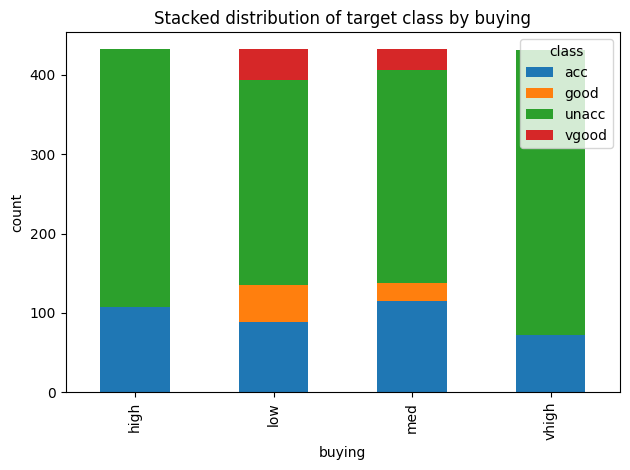

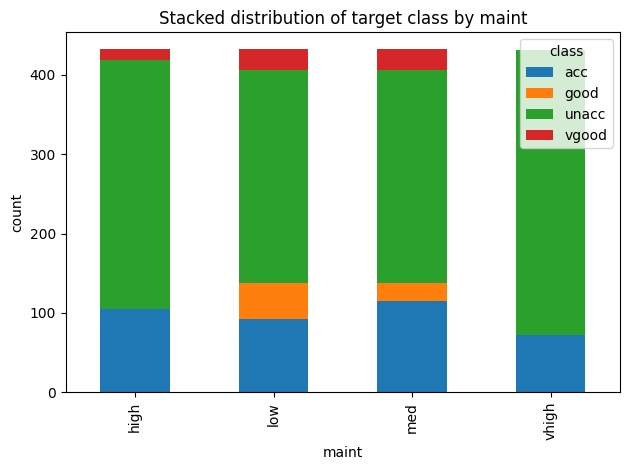

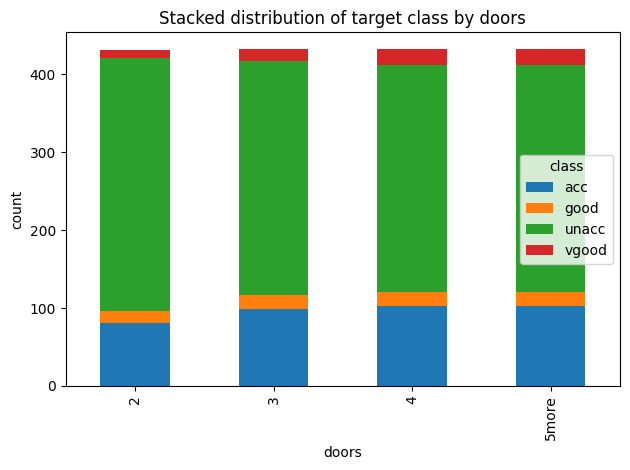

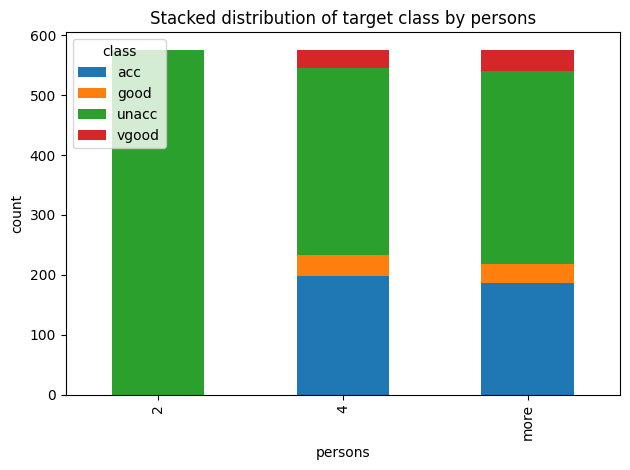

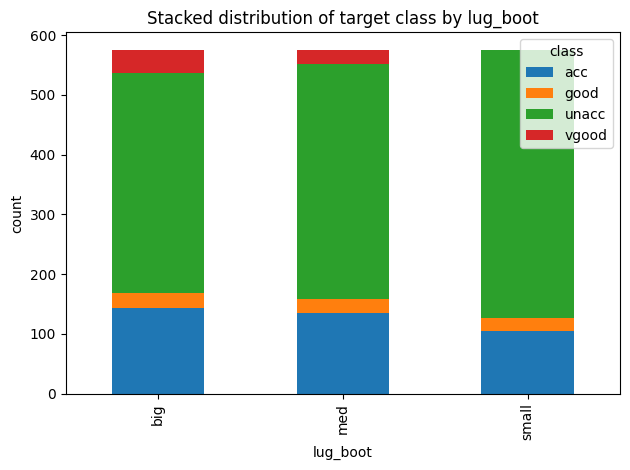

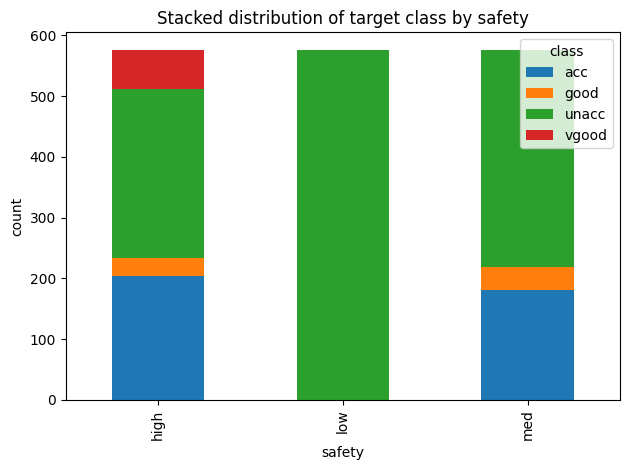

In [ ]:

for col in X_COLS:
    ct = pd.crosstab(df[col], df["class"])
    ax = ct.plot(kind="bar", stacked=True)
    ax.set_title(f"Stacked distribution of target class by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


## 11. Mean Target Score by Feature Level
This cell treats the encoded target y as an ordinal numeric score and computes the mean y for each feature level. The resulting bar charts provide a clear, interpretable signal of which feature levels tend to correspond to “better” or “worse” outcomes on average.

Bar-label helper is ready.


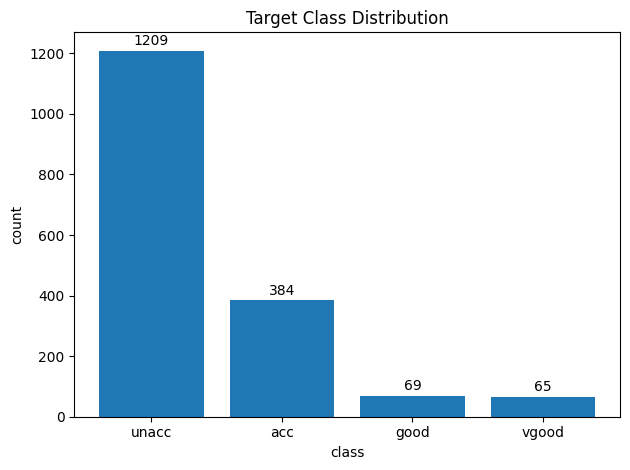

,count
class,
unacc,1209
acc,384
good,69
vgood,65


In [17]:

def add_bar_labels(ax, fmt="{:.0f}", padding=2):
    """
    Add numeric labels above bars for bar charts (matplotlib/seaborn).
    """
    for p in ax.patches:
        h = p.get_height()
        if h is None or (isinstance(h, float) and np.isnan(h)):
            continue
        ax.annotate(
            fmt.format(h),
            (p.get_x() + p.get_width()/2.0, h),
            ha="center", va="bottom",
            textcoords="offset points",
            xytext=(0, padding)
        )

print("Bar-label helper is ready.")

target_counts = df["class"].value_counts()

plt.figure()
ax = plt.gca()
ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_title("Target Class Distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
add_bar_labels(ax, fmt="{:.0f}")
plt.tight_layout()
plt.show()

target_counts

## 12. Feature Frequency Distributions with Data Labels

This cell produces one bar chart per feature to show the frequency of each category level. Each bar is annotated with its count value

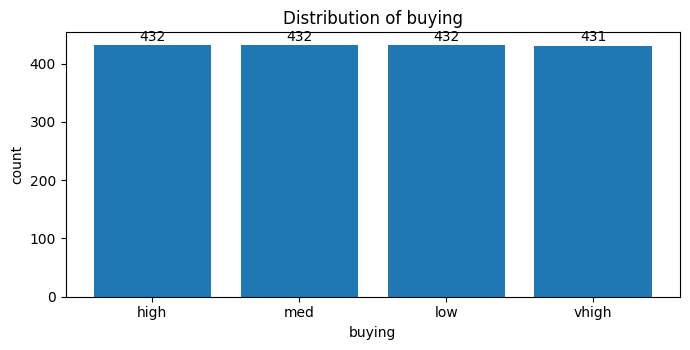

,count
buying,
high,432
med,432
low,432
vhigh,431


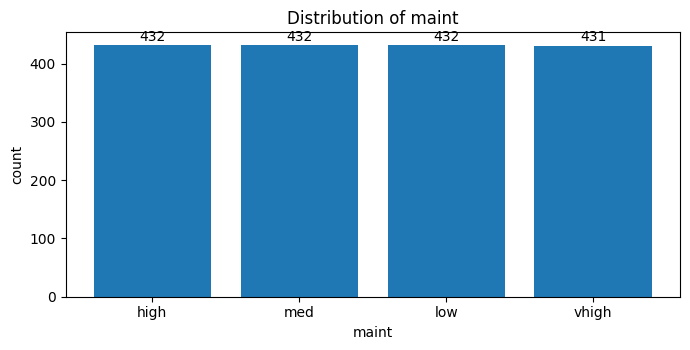

,count
maint,
high,432
med,432
low,432
vhigh,431


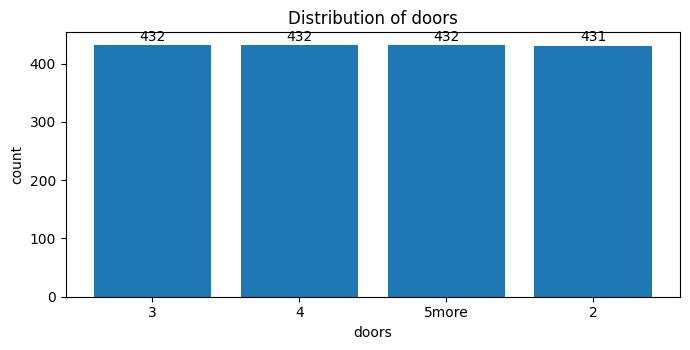

,count
doors,
3,432
4,432
5more,432
2,431


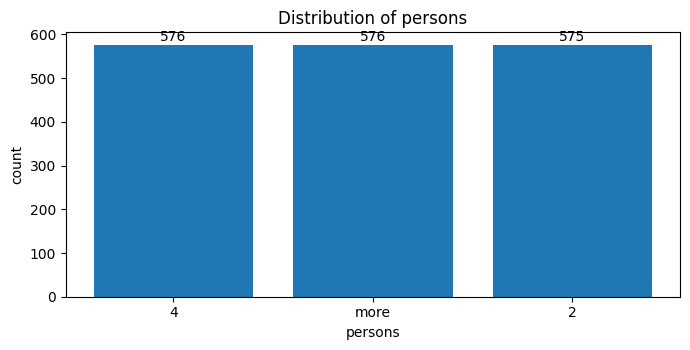

,count
persons,
4,576
more,576
2,575


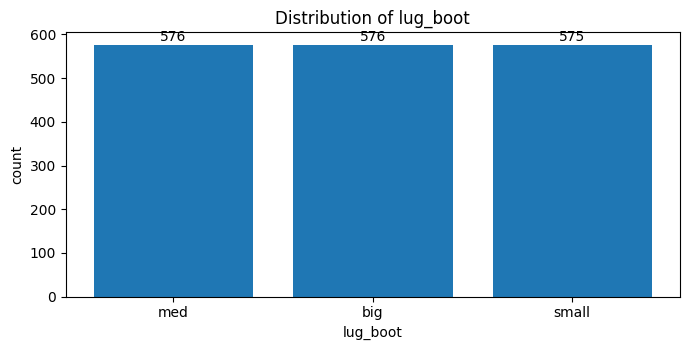

,count
lug_boot,
med,576
big,576
small,575


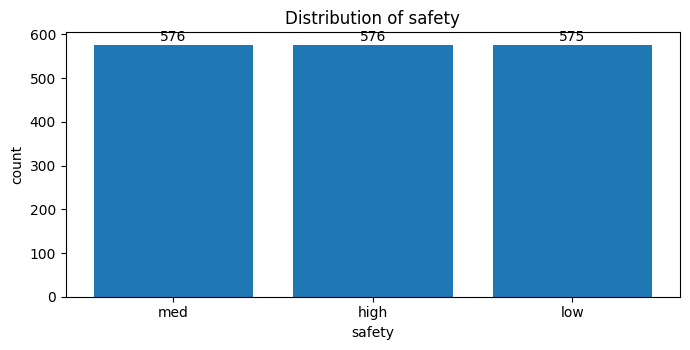

,count
safety,
med,576
high,576
low,575


In [18]:
for col in X_COLS:
    vc = df[col].value_counts()
    plt.figure(figsize=(7, 3.6))
    ax = plt.gca()
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    add_bar_labels(ax, fmt="{:.0f}", padding=1)
    plt.tight_layout()
    plt.show()

    display(vc)


## 13. Regression Tree Measure Metrics

This cell generates test-set predictions from your existing regression tree (with robust node-field handling) and reports core regression metrics: MSE, RMSE, MAE, and R². These metrics are standard for SSE-based regression trees and do not rely on any classification-only outputs.

In [19]:
# Predict
y_pred = predict(tree, X_test).astype(float)
y_true = y_test.astype(float)

# Regression metrics (numpy only)
mse = float(np.mean((y_true - y_pred) ** 2))
rmse = float(np.sqrt(mse))
mae = float(np.mean(np.abs(y_true - y_pred)))

ss_res = float(np.sum((y_true - y_pred) ** 2))
ss_tot = float(np.sum((y_true - float(np.mean(y_true))) ** 2))
r2 = float(1.0 - (ss_res / ss_tot)) if ss_tot > 0 else float("nan")

metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2"],
    "Value": [mse, rmse, mae, r2]
})
metrics_df


,Metric,Value
0,MSE,2.694543
1,RMSE,1.641506
2,MAE,1.426475
3,R2,-3.905113


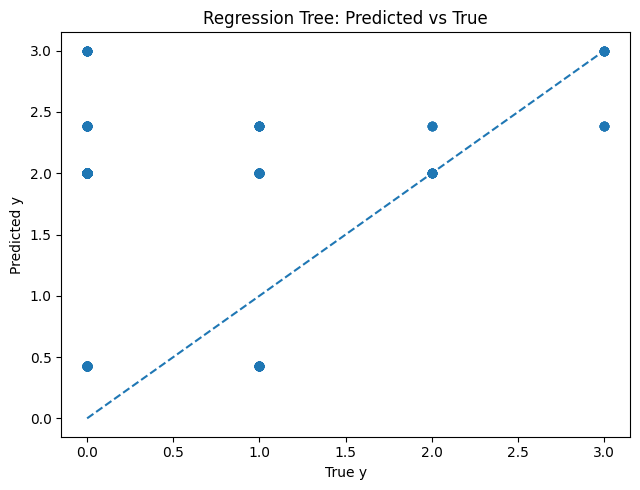

In [20]:
plt.figure(figsize=(6.5, 5))
plt.scatter(y_true, y_pred)

lo = float(min(np.min(y_true), np.min(y_pred)))
hi = float(max(np.max(y_true), np.max(y_pred)))
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.title("Regression Tree: Predicted vs True")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.tight_layout()
plt.show()


## 14. Root-Level Split Diagnostics (Best SSE Gain per Feature) with Robust Function Call

This cell measures, for each feature, the best achievable SSE reduction (“gain”) at the root node. The implementation is robust to different best_split_categorical signatures (3-argument or 4-argument versions), so it runs without modifying earlier cells.

,feature,best_gain_at_root,best_left_values
0,buying,173.588497,"(high, med, vhigh)"
5,safety,110.427689,"(high, med)"
1,maint,46.323030,"(high, vhigh)"
3,persons,27.703802,"(2, more)"
4,lug_boot,21.139600,"(big, med)"
2,doors,1.602491,"(2, 3)"


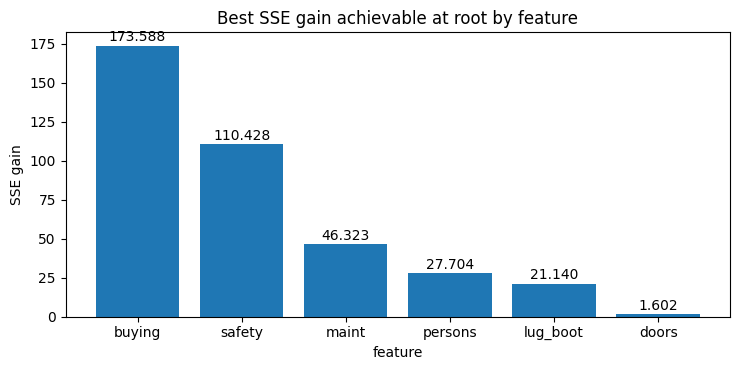

In [ ]:
MIN_SAMPLES_LEAF_DIAG = 15
root_sse = sse_of_targets(y_train)

def _call_best_split(X, y, feature):
    # Try keyword argument
    try:
        return best_split_categorical(X, y, feature, min_samples_leaf=MIN_SAMPLES_LEAF_DIAG)
    except TypeError:
        pass
    # Try positional 4th argument
    try:
        return best_split_categorical(X, y, feature, MIN_SAMPLES_LEAF_DIAG)
    except TypeError:
        pass
    # Fallback: 3-arg version
    globals()["MIN_SAMPLES_LEAF"] = MIN_SAMPLES_LEAF_DIAG
    globals()["min_samples_leaf"] = MIN_SAMPLES_LEAF_DIAG
    return best_split_categorical(X, y, feature)

def _parse_candidate(cand):
    """
    Return (sse_split, left_values) from cand.
    Supports:
      - dict with keys: sse_split / left_values
      - tuple/list with various layouts
    """
    if cand is None:
        return (np.nan, None)

    # Case 1: dict
    if isinstance(cand, dict):
        sse_split = cand.get("sse_split", np.nan)
        left_values = cand.get("left_values", None)
        return (float(sse_split) if sse_split is not None else np.nan, left_values)

    # Case 2: tuple/list
    if isinstance(cand, (tuple, list)):
        # Heuristic:
        # - sse_split is usually a float
        # - left_values is often a tuple/list/set of category values
        sse_split = None
        left_values = None

        # find first float-like item for sse_split
        for item in cand:
            if isinstance(item, (float, int, np.floating, np.integer)):
                sse_split = float(item)
                break

        # find first "collection-like" item for left_values (excluding numpy arrays / masks)
        for item in cand:
            if isinstance(item, (set, tuple, list)) and not isinstance(item, np.ndarray):
                # avoid picking a mask if it's a list of bools
                if len(item) > 0 and all(isinstance(x, (bool, np.bool_)) for x in item):
                    continue
                left_values = item
                break

        return (sse_split if sse_split is not None else np.nan, left_values)

    # unknown format
    return (np.nan, None)

rows = []
for f in X_train.columns:
    cand = _call_best_split(X_train, y_train, f)
    sse_split, left_values = _parse_candidate(cand)

    if np.isnan(sse_split):
        rows.append((f, np.nan, left_values))
    else:
        gain = root_sse - sse_split
        rows.append((f, gain, left_values))

diag = pd.DataFrame(rows, columns=["feature", "best_gain_at_root", "best_left_values"]) \
         .sort_values("best_gain_at_root", ascending=False)

display(diag)

plt.figure(figsize=(7.5, 3.8))
ax = plt.gca()
vals = diag["best_gain_at_root"].fillna(0.0).values
ax.bar(diag["feature"].astype(str), vals)
ax.set_title("Best SSE gain achievable at root by feature")
ax.set_xlabel("feature")
ax.set_ylabel("SSE gain")
add_bar_labels(ax, fmt="{:.3f}", padding=1)
plt.tight_layout()
plt.show()

## 15. Sklearn Regression Tree Visualization

This cell fits a CART regression tree using scikit-learn on the same dataset and visualizes the learned tree with sklearn.tree.plot_tree. Categorical features are one-hot encoded. The plotted tree uses expanded feature names produced by the encoder.

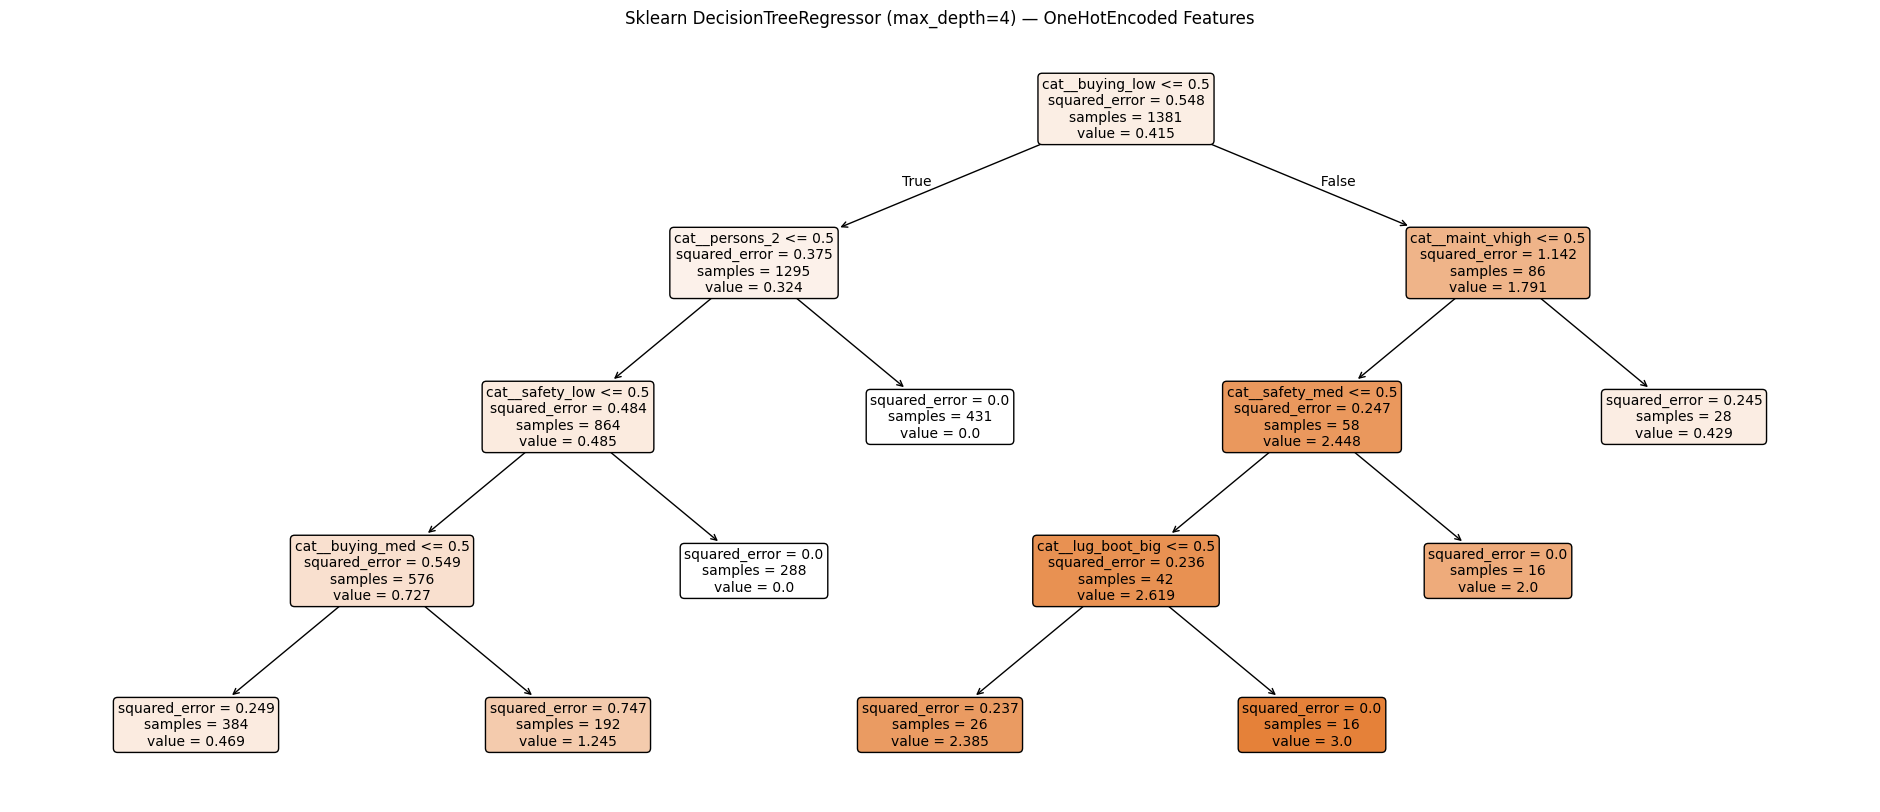

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1) Prepare X, y (regression target)
X = df[X_COLS].copy()
y = df["y"].astype(float).values

# 2) Deterministic split (reuse your existing train_df/test_df if available)
if "train_df" in globals() and "test_df" in globals():
    X_train_s = train_df[X_COLS].copy()
    y_train_s = train_df["y"].astype(float).values
    X_test_s  = test_df[X_COLS].copy()
    y_test_s  = test_df["y"].astype(float).values
else:
    # fallback: first 80% as train, last 20% as test (deterministic)
    cut = int(np.floor(len(df) * 0.8))
    X_train_s, X_test_s = X.iloc[:cut], X.iloc[cut:]
    y_train_s, y_test_s = y[:cut], y[cut:]

# 3) Preprocess: one-hot encode all categorical columns
pre = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), X_COLS)],
    remainder="drop"
)

# 4) Model: keep depth small so the plot is readable
reg = DecisionTreeRegressor(max_depth=4, min_samples_leaf=15, random_state=0)

pipe = Pipeline(steps=[("pre", pre), ("model", reg)])
pipe.fit(X_train_s, y_train_s)

# 5) Extract feature names after one-hot encoding
feature_names = pipe.named_steps["pre"].get_feature_names_out()

# 6) Plot tree
plt.figure(figsize=(24, 10))
plot_tree(
    pipe.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Sklearn DecisionTreeRegressor (max_depth=4) — OneHotEncoded Features")
plt.show()


## 16. Summary

This notebook applied a from-scratch CART regression tree to the Car Evaluation dataset by treating the ordinal class labels as numeric scores (unacc=0, acc=1, good=2, vgood=3). However, the regression approach proved fundamentally unsuitable for this problem, as evidenced by the highly negative R² value of -3.91, indicating that the model performs worse than simply predicting the mean value for all observations.

The poor regression performance stems from a critical mismatch between the problem structure and the modeling approach. The Car Evaluation dataset exhibits severe class imbalance (70% unacc, 22% acc, 4% good, 4% vgood), and the ordinal encoding forces the model to minimize squared distance in a numeric space where the "true" relationship is categorical, not continuous. The mean target score is 0.41 (heavily skewed toward unacc=0), and the tree struggles to capture the discrete jumps between evaluation levels.

The root-level split diagnostics revealed that `buying` provides the strongest SSE reduction (173.6), followed by `safety` (110.4), suggesting these features are the most informative for partitioning the data. However, even with optimal splits on these features, the regression framework cannot adequately model the discrete, non-continuous nature of the target variable. The predicted vs. true scatter plot shows that predictions cluster around a few discrete values (corresponding to leaf node means) but fail to align with the actual ordinal levels.

This analysis demonstrates a key machine learning principle: **task formulation matters as much as algorithm choice**. While regression trees are powerful for continuous numeric targets, forcing a classification problem into a regression framework—even with ordinal encoding—can produce meaningless results. The negative R² value serves as a clear diagnostic that classification would have been the appropriate approach for this dataset, as shown in the companion classification notebook where the same algorithm achieved 82.9% accuracy by respecting the categorical nature of the target variable.